# Plotting Boresch restraint geometry for a SepTop complex leg

This notebook checks that a Boresch restraint stayed well-behaved during a SepTop
complex-leg simulation, by plotting the restraint's bond, two angles, and three
dihedrals against their equilibrium reference values, for the first and last
lambda windows, for every repeat found in the results JSON.

The only input you need is the results JSON from `openfe quickrun` (or however
your SepTop transformation was executed). Trajectory files, subsampled PDB
topologies, and restraint geometries are located automatically per repeat
from paths recorded inside the JSON.

**If you ran the simulation on a cluster and are analyzing locally** (like in this example), those
recorded paths (`shared_basepath` at run time) likely won't resolve on your
machine. Section 5 below lets you override the trajectory/PDB paths per
repeat with local copies; leave it empty to use the JSON paths as-is. A
repeat whose files aren't found (and has no override) is skipped with a
clear message rather than stopping the whole notebook.

## 1. Imports

In [1]:
import json
import pathlib
import pooch

import matplotlib.pyplot as plt
import MDAnalysis as mda
import numpy as np
from gufe.tokenization import JSON_HANDLER
from MDAnalysis.lib.distances import calc_angles, calc_bonds, calc_dihedrals
from openfe_analysis import FEReader
from openff.units import Quantity, unit
from openmmtools import multistate

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



## 2. Download tutorial data

In [2]:
septop_files = pooch.retrieve(
    url="https://zenodo.org/records/21164997/files/septop_boresch_analysis.tar.gz",
    known_hash="md5:00473a051af5188fb74dfe8eeb1d4db4",
    processor=pooch.Untar(extract_dir="septop_boresch_analysis"),
)

# Extract the individual file paths
septop_paths = {pathlib.Path(f).suffix: pathlib.Path(f) for f in septop_files}
results_json = septop_paths[".json"]
trajectory_nc = septop_paths[".nc"]
subsampled_pdb = septop_paths[".pdb"]

## 3. Load the results JSON

In [3]:
with open(results_json, "r") as f:
    results = json.load(f, cls=JSON_HANDLER.decoder)

## 4. Find the complex-leg Analysis unit outputs for every repeat

A SepTop results JSON contains one `ProtocolUnitResult` entry per protocol
unit that ran: a Setup, Simulation, and Analysis unit per repeat per leg.

The complex-leg **Analysis** unit's outputs contains everything we
need: 
- `restraint_geometry_A/B`,
- `subsampled_pdb_structure`
- `selection_indices`, and
- `trajectory`

In [4]:
complex_analysis_by_repeat = {}

for key, unit_result in results["unit_results"].items():
    if not key.startswith("ProtocolUnitResult"):
        continue
    if "Analysis" not in unit_result.get("name", ""):
        continue
    outputs = unit_result["outputs"]
    if outputs.get("simtype") != "complex":
        continue
    complex_analysis_by_repeat[outputs["repeat_id"]] = outputs

complex_repeats = sorted(complex_analysis_by_repeat.items())

## 5. Optional: override file paths for local analysis

Since in this example we copied the files down locally, we fill in local paths here, keyed by
the `[index]` shown in the listing above.

In [5]:
LOCAL_PATH_OVERRIDES: dict[int, dict[str, str]] = {
    0: {
        "trajectory": trajectory_nc,
        "subsampled_pdb_structure": subsampled_pdb,
    },
}

## 6. Helper: compute Boresch geometry from an atom group

We write a helper function computing the bond, two
angles, and three dihedrals from six atoms ordered
`[H0, H1, H2, G0, G1, G2]` (host atoms then guest atoms).

In [6]:
def get_restraint_distances(atomgroup: mda.AtomGroup) -> tuple:
    """
    Compute the Boresch restraint's bond, 2 angles, and 3 dihedrals from
    an AtomGroup of exactly 6 atoms, ordered [H0, H1, H2, G0, G1, G2].

    Returns
    -------
    tuple of openff.units.Quantity
        (bond, angle1, angle2, dihedral1, dihedral2, dihedral3)
    """
    bond = calc_bonds(
        atomgroup.atoms[0].position,
        atomgroup.atoms[3].position,
        box=atomgroup.dimensions,
    ) * unit.angstroms

    angles = []
    for idx_set in [[1, 0, 3], [0, 3, 4]]:
        angle = calc_angles(
            atomgroup.atoms[idx_set[0]].position,
            atomgroup.atoms[idx_set[1]].position,
            atomgroup.atoms[idx_set[2]].position,
            box=atomgroup.dimensions,
        )
        angles.append(angle * unit.radians)

    dihedrals = []
    for idx_set in [[2, 1, 0, 3], [1, 0, 3, 4], [0, 3, 4, 5]]:
        dihedral = calc_dihedrals(
            atomgroup.atoms[idx_set[0]].position,
            atomgroup.atoms[idx_set[1]].position,
            atomgroup.atoms[idx_set[2]].position,
            atomgroup.atoms[idx_set[3]].position,
            box=atomgroup.dimensions,
        )
        dihedrals.append(dihedral * unit.radians)

    return bond, angles[0], angles[1], dihedrals[0], dihedrals[1], dihedrals[2]

## 7. Helper: translate full-system atom indices

`host_atoms`/`guest_atoms` from the restraint geometry are full-system
indices, but the trajectory only contains the subsampled atoms. We need to
find each restraint atom's position within `selection_indices`.

In [7]:
def translate_to_subsampled_indices(full_system_indices, selection_indices):
    selection_indices_list = selection_indices.tolist()
    return [selection_indices_list.index(idx) for idx in full_system_indices]

## 8. Helper: reconstruct a Quantity from the stored restraint geometry

Restraint geometry fields (`r_aA0`, `theta_A0`, ...) are gufe `Quantity`
fields, serialized as `{"val": <float>, "unit": "<pint unit string>"}`. We reconstruct a real `openff.units.Quantity` and convert
explicitly.

In [8]:
def quantity_from_geom(geom: dict, key: str) -> Quantity:
    field = geom[key]
    return Quantity(field["val"], field["unit"])

## 9. Helper: plot the restraint geometry across lambda windows

This loads each lambda window's trajectory via `FEReader` (an MDAnalysis
reader for openmmtools multistate NetCDF files), computes the restraint
geometry at every frame, and plots it against the restraint's reference
values.

In [9]:
def plot_boresch_restraint(
    trajectory_nc,
    subsampled_pdb,
    lambda_windows,
    host_atoms,
    guest_atoms,
    reference_values,
    ligand_label,
):
    fig = plt.figure(figsize=(8, 4))
    titles = ["bond", "angle1", "angle2", "dih1", "dih2", "dih3"]

    for window in lambda_windows:
        u = mda.Universe(
            subsampled_pdb,
            trajectory_nc,
            format=FEReader,
            index=window,
            index_method="state",
        )
        try:
            atomgroup = u.atoms[host_atoms + guest_atoms]
            values = [get_restraint_distances(atomgroup) for _ in u.trajectory]
        finally:
            u.trajectory.close()

        per_quantity = [[v[i].m for v in values] for i in range(6)]

        for i in range(6):
            plt.subplot(2, 3, i + 1)
            plt.plot(per_quantity[i], label=f"lambda_{window}")
            plt.plot(
                [reference_values[i]] * len(per_quantity[i]),
                "--",
                c="black",
            )
            plt.title(titles[i])
            if i == 0:
                plt.legend(fontsize=7)

    fig.suptitle(f"Boresch restraint - {ligand_label}", fontsize=10)
    fig.tight_layout()
    return fig

## 10. Run it for every repeat and ligand

For each repeat found, we locate its trajectory and subsampled PDB, work out
the lambda window count, and generate a plot per ligand (A and B).

Could not locate checkpoint subfile. This is okay for analysis if the solvent trajectory is not needed, but not for production simulation!


Repeat 56935576443687670529904559640479965869: 19 lambda windows; plotting [0, 18]


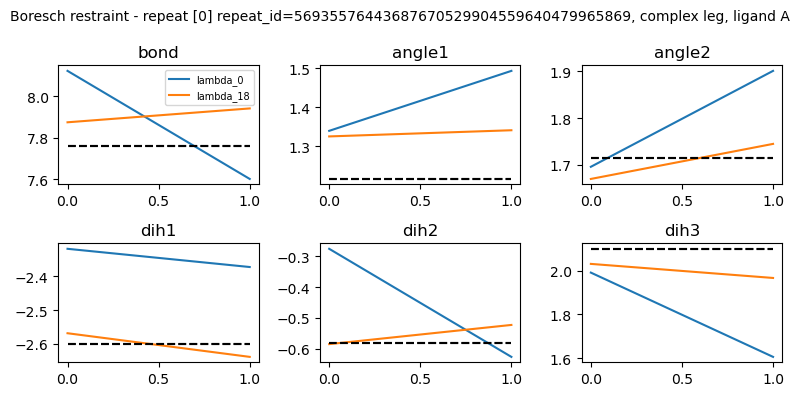

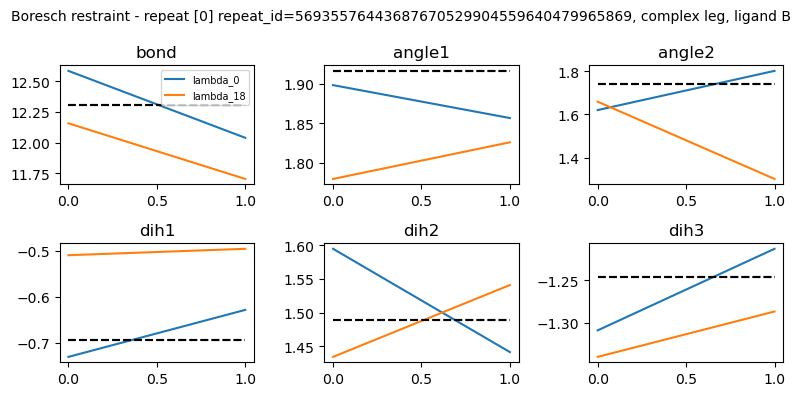

In [10]:
for idx, (repeat_id, outputs) in enumerate(complex_repeats):
    overrides = LOCAL_PATH_OVERRIDES.get(idx, {})
    trajectory_nc = pathlib.Path(overrides.get("trajectory", outputs["trajectory"]))
    subsampled_pdb = pathlib.Path(
        overrides.get("subsampled_pdb_structure", outputs["subsampled_pdb_structure"])
    )

    if not trajectory_nc.exists() or not subsampled_pdb.exists():
        print(
            f"Skipping repeat [{idx}] (repeat_id={repeat_id}): trajectory or PDB "
            f"not found ({trajectory_nc}, {subsampled_pdb}). If these are the "
            "original cluster paths, either run this notebook on that filesystem, "
            f"or add a local override for LOCAL_PATH_OVERRIDES[{idx}] above."
        )
        continue

    selection_indices = np.asarray(outputs["selection_indices"])

    reporter = multistate.MultiStateReporter(storage=str(trajectory_nc), open_mode="r")
    n_states = reporter.n_states
    reporter.close()
    lambda_windows = [0, n_states - 1] if n_states > 1 else [0]
    print(f"Repeat {repeat_id}: {n_states} lambda windows; plotting {lambda_windows}")

    for ligand in ("A", "B"):
        geom_key = f"restraint_geometry_{ligand}"
        geom = outputs[geom_key]
        host_atoms_full = geom["host_atoms"]
        guest_atoms_full = geom["guest_atoms"]

        host_atoms = translate_to_subsampled_indices(host_atoms_full, selection_indices)
        guest_atoms = translate_to_subsampled_indices(guest_atoms_full, selection_indices)

        # calc_bonds/calc_angles/calc_dihedrals report bond length in
        # Angstrom and angle/dihedral in radians.
        reference_values = [
            quantity_from_geom(geom, "r_aA0").m_as(unit.angstrom),
            quantity_from_geom(geom, "theta_A0").m_as(unit.radians),
            quantity_from_geom(geom, "theta_B0").m_as(unit.radians),
            quantity_from_geom(geom, "phi_A0").m_as(unit.radians),
            quantity_from_geom(geom, "phi_B0").m_as(unit.radians),
            quantity_from_geom(geom, "phi_C0").m_as(unit.radians),
        ]

        fig = plot_boresch_restraint(
            trajectory_nc,
            subsampled_pdb,
            lambda_windows,
            host_atoms,
            guest_atoms,
            reference_values,
            ligand_label=f"repeat [{idx}] repeat_id={repeat_id}, complex leg, ligand {ligand}",
        )
        plt.show()
        plt.close(fig) 

## What to look for

For a well-behaved restraint, each quantity (bond, angle1, angle2, dih1,
dih2, dih3) should fluctuate around its dashed reference line, for both the
first and last lambda window. If a quantity sits at a
consistent offset from the reference line rather than fluctuating around it,
or if this differs markedly between repeats, that's worth investigating.
However, SepTop can pick a different Boresch restraint per repeat, so
some repeat-to-repeat variation in the reference values themselves is
expected.